
MODEL: Random Forest
Accuracy: 0.9792
F1 Score (Weighted): 0.9788

Confusion Matrix:
[[26  0  0  0]
 [ 0  5  0  1]
 [ 0  0  8  0]
 [ 0  0  0  8]]

Class-wise Report (Precision, Recall, F1, Support):
                      precision    recall  f1-score   support

             Healthy       1.00      1.00      1.00        26
  Nitrogen_Deficient       1.00      0.83      0.91         6
Phosphorus_Deficient       1.00      1.00      1.00         8
 Potassium_Deficient       0.89      1.00      0.94         8

            accuracy                           0.98        48
           macro avg       0.97      0.96      0.96        48
        weighted avg       0.98      0.98      0.98        48


MODEL: Decision Tree
Accuracy: 0.9583
F1 Score (Weighted): 0.9583

Confusion Matrix:
[[26  0  0  0]
 [ 0  5  0  1]
 [ 0  0  8  0]
 [ 0  1  0  7]]

Class-wise Report (Precision, Recall, F1, Support):
                      precision    recall  f1-score   support

             Healthy       1.00      1

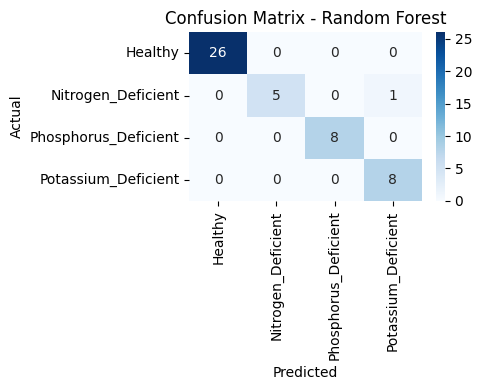

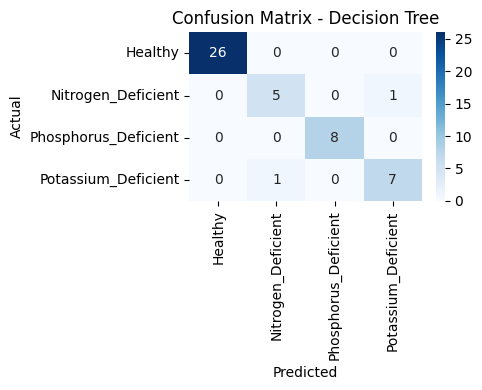

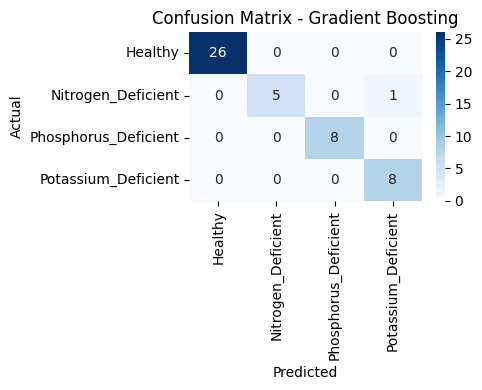

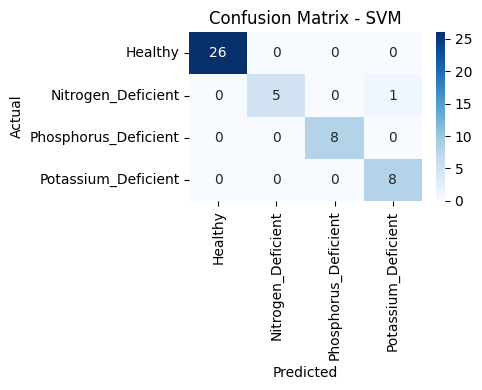

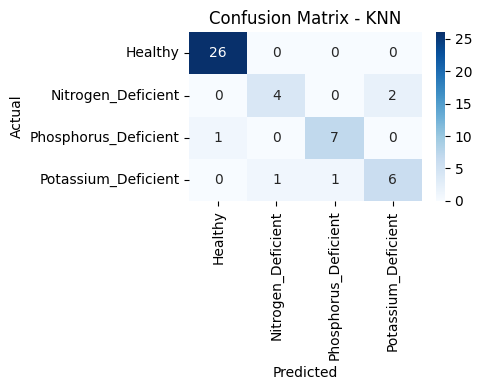

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# ── 1. Load Data ─────────────────────────────────────
df = pd.read_excel('/content/hydrogrow_final_v6.xlsx')

# Encode labels
le_phase = LabelEncoder()
le_label = LabelEncoder()

df['Growth_Phase_enc'] = le_phase.fit_transform(df['Growth_Phase'])
df['Label_enc'] = le_label.fit_transform(df['Label'])

# Features
feature_cols = ['Growth_Day', 'Growth_Phase_enc', 'pH', 'EC (mS/cm)',
                'Air_Temp (°C)', 'Humidity (%)', 'Water_Level (%)', 'Treatment_%']

X = df[feature_cols]
y = df['Label_enc']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

classes = le_label.classes_

# ── 2. Models ─────────────────────────────────────
models = {
    'Random Forest': (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'Decision Tree': (DecisionTreeClassifier(max_depth=8, random_state=42), False),
    'Gradient Boosting': (GradientBoostingClassifier(n_estimators=200, random_state=42), False),
    'SVM': (SVC(kernel='rbf', probability=True, random_state=42), True),
    'KNN': (KNeighborsClassifier(n_neighbors=7), True)
}

# ── 3. Train & Print Results ─────────────────────
for name, (model, scale) in models.items():

    Xtr = X_train_sc if scale else X_train
    Xte = X_test_sc if scale else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=classes)

    print("\n" + "="*50)
    print(f"MODEL: {name}")
    print("="*50)

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (Weighted): {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClass-wise Report (Precision, Recall, F1, Support):")
    print(report)
    # ── Plot Confusion Matrices ─────────────────────
for name, (model, scale) in models.items():

    Xtr = X_train_sc if scale else X_train
    Xte = X_test_sc if scale else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── 3. Train & Print Results ─────────────────────
results = []

for name, (model, scale) in models.items():

    Xtr = X_train_sc if scale else X_train
    Xte = X_test_sc if scale else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # 🔥 ADD THIS (explicit metrics)
    from sklearn.metrics import precision_score, recall_score

    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=classes)

    print("\n" + "="*50)
    print(f"MODEL: {name}")
    print("="*50)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClass-wise Report:")
    print(report)

    # store summary for comparison table
    results.append([name, acc, precision, recall, f1])

# ── FINAL COMPARISON TABLE ─────────────────────
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

print("\n\n🔥 FINAL MODEL COMPARISON:")
print(results_df.sort_values(by="F1 Score", ascending=False))


MODEL: Random Forest
Accuracy : 0.9792
Precision: 0.9815
Recall   : 0.9792
F1 Score : 0.9788

Confusion Matrix:
[[26  0  0  0]
 [ 0  5  0  1]
 [ 0  0  8  0]
 [ 0  0  0  8]]

Class-wise Report:
                      precision    recall  f1-score   support

             Healthy       1.00      1.00      1.00        26
  Nitrogen_Deficient       1.00      0.83      0.91         6
Phosphorus_Deficient       1.00      1.00      1.00         8
 Potassium_Deficient       0.89      1.00      0.94         8

            accuracy                           0.98        48
           macro avg       0.97      0.96      0.96        48
        weighted avg       0.98      0.98      0.98        48


MODEL: Decision Tree
Accuracy : 0.9583
Precision: 0.9583
Recall   : 0.9583
F1 Score : 0.9583

Confusion Matrix:
[[26  0  0  0]
 [ 0  5  0  1]
 [ 0  0  8  0]
 [ 0  1  0  7]]

Class-wise Report:
                      precision    recall  f1-score   support

             Healthy       1.00      1.00      1.0